# Neural Network Model Creation Summary

We will cover a summary of the main steps for creating a neural network model from data preprocessing to model evaluation:

1. Introduction to the dataset and problem statement.
2. Data preprocessing and exploration.
3. Dataset and Dataloader creation using PyTorch.
4. Neural Network model definition. Cost function and optimizer selection.
5. Model training and validation.
6. Model evaluation and metrics calculation.

Additionaly, a summary of the main points between Classical ML and Deep Learning:
- Neural networks can do classification/regression, but they are not always better.
- Classical ML is faster, more interpretable, and works well on small datasets.
- Learning classical ML gives intuition that makes deep learning much easier to understand.
- Deep Learning shines with large datasets and complex patterns, especially in unstructured data like images and text.

> Finally, this lab will use PyTorch as the main framework for building and training neural networks, instead of TensorFlow/Keras used in previous labs.


## 1. Introduction to the dataset and problem statement.

Classification of (Breast Cancer Wisconsin (Diagnostic) Dataset)[https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data] using a Neural Network implemented in PyTorch.

Attribute Information:

1) ID number
2) Diagnosis (M = malignant, B = benign) - Variable to predict

Ten real-valued features are computed for each cell nucleus:

a) radius (mean of distances from center to points on the perimeter)

b) texture (standard deviation of gray-scale values)

c) perimeter

d) area

e) smoothness (local variation in radius lengths)

f) compactness (perimeter^2 / area - 1.0)

g) concavity (severity of concave portions of the contour)

h) concave points (number of concave portions of the contour)

i) symmetry

j) fractal dimension ("coastline approximation" - 1)

The mean, standard error and "worst" or largest (mean of the three
largest values) of these features were computed for each image,
resulting in 30 features. For instance, field 3 is Mean Radius, field
13 is Radius SE, field 23 is Worst Radius.

All feature values are recoded with four significant digits.

Missing attribute values: none

Class distribution: 357 benign, 212 malignant

> We are not going to use the photo images, just the features extracted from them.

Learning process:
- Training cycle: Data & Validation -> Neural Network -> Prediction -> Error calculation / costs (comparing prediction with true labels) using gradient descent -> Backpropagation / Update weights (using optimizer with costs) -> Back to Neural Network ...
- Repeat for many epochs until the model converges.

## 2. Data preprocessing and exploration.

We load the required libraries and the dataset, check for missing values, encode categorical variables, split the data into features and labels, and perform train-test split. We also standardize the feature values to have mean 0 and variance 1.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

import time

### Dataset Preparation

1. Analysis of dataset structure and content.
2. Data cleaning: Handling missing values and outliers.
3. Data Preprocessing: Encoding categorical variables, feature scaling/normalization.

In [5]:
data = pd.read_csv('datasets/breast_cancer.csv')
data.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
print(data.dtypes)

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

We can drop the 'id' column as it does not contribute to the prediction task and Unnamed: 32 is just an index.

In [7]:
data = data.drop(['id', 'Unnamed: 32'], axis=1)
data.head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#### Analysis of the dataset

In [8]:
data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


We see we have 569 samples with 30 features each. The target variable 'diagnosis' is categorical with two classes: 'M' (malignant) and 'B' (benign). There are no missing values in the dataset. The features have varying scales, so we will need to standardize them before training the neural network.

Now let's see the distribution of the target variable 'diagnosis' to understand the class balance in the dataset.

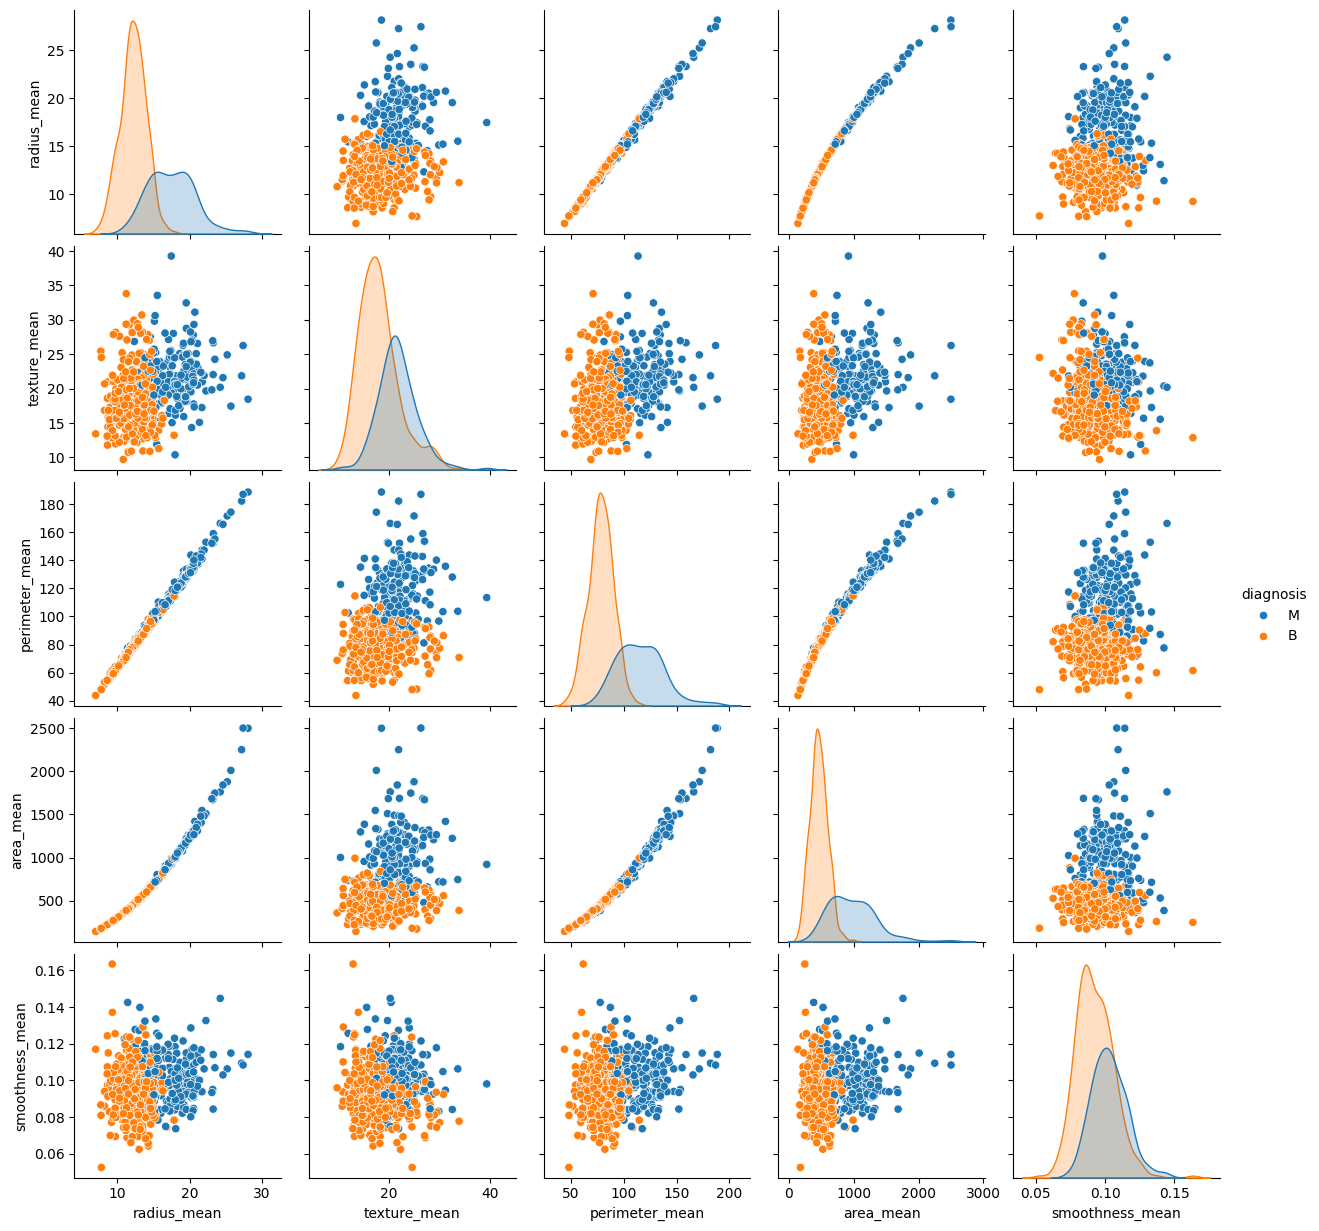

In [9]:
sns.pairplot(data, hue='diagnosis', vars=data.columns[1:6])

The dataset is slightly imbalanced with more benign cases than malignant ones. From the pairplot, we can observe that some features show clear separation between the two classes, which is promising for classification tasks. However, there is also overlap in some features, indicating that a more complex model like a neural network may be beneficial for capturing these patterns.

Let's draw some histograms to see the distribution and frequency of the different features.
> It's another way to visualization of the distribution of the features.

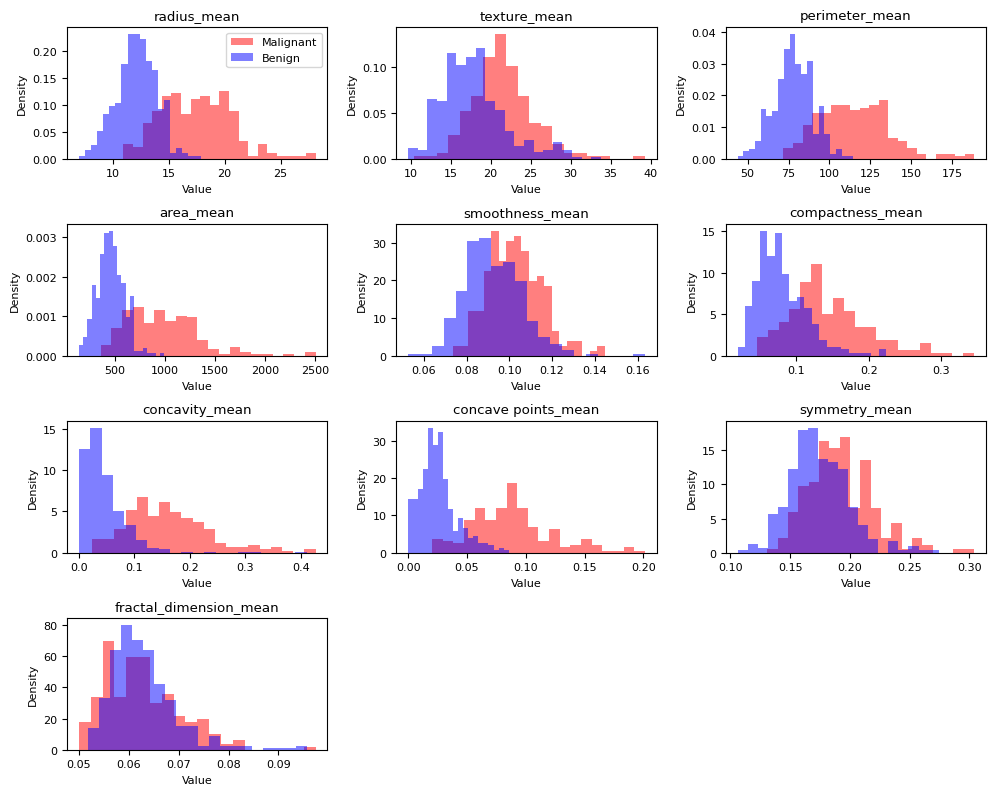

In [18]:
features = list(data.columns[1:11])  # skip 'diagnosis'
dfM = data[data['diagnosis']=='M']
dfB = data[data['diagnosis']=='B']

plt.rcParams.update({'font.size': 8})

# Dynamically calculate rows/columns
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 8))
axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < n_features:
        # density=True for normalized histograms
        ax.hist(dfM[features[i]], bins=20, alpha=0.5, label='Malignant', color='red', density=True)
        ax.hist(dfB[features[i]], bins=20, alpha=0.5, label='Benign', color='blue', density=True)
        ax.set_title(features[i])
        ax.set_ylabel('Density')
        ax.set_xlabel('Value')
        if i == 0:
            ax.legend()  # show legend only on the first plot
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()


Now we will analysis the variable to predict 'diagnosis' to see the balance of classes in the dataset.

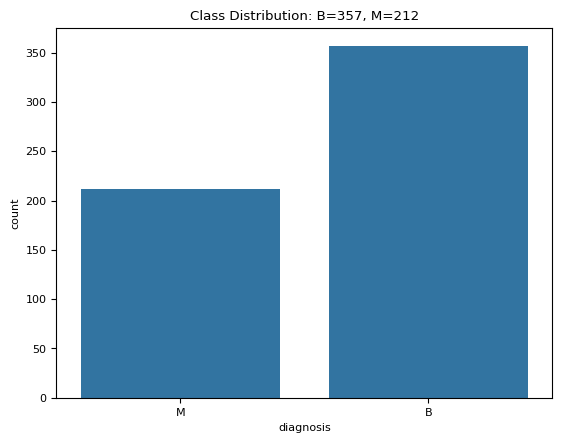

In [19]:
ax = sns.countplot(x='diagnosis', data=data)
B, M = data['diagnosis'].value_counts()
plt.title(f'Class Distribution: B={B}, M={M}')
plt.show()

#### Cleaning the dataset

In [20]:
print(data.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


#### Prepocessing the dataset
1. Encoding categorical variables
2. Feature scaling/normalization (really important for neural networks)
3. Train-test split

We codify categorical variable 'diagnosis' to numerical values: 'B' to 0 and 'M' to 1 for binary classification.

In [21]:
data['diagnosis'] = data['diagnosis'].map({'B':0, 'M':1})
data.head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


We separate data into training (65%), validation (20%), and test (15%) sets to evaluate model performance on unseen data.

Scaling the data is crucial for neural networks as they are sensitive to the scale of input features. Standardization (mean=0, variance=1) helps in faster convergence during training.
> It can also be scaled using Normalization (scaling features to a range, e.g., [0, 1] or [-1, 1]), but standardization is often preferred for neural networks.

In [22]:
y = data['diagnosis'].copy()
X = data.drop('diagnosis', axis=1)
print(X.shape, y.shape)

(569, 30) (569,)


In [24]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, shuffle=True)

print(f"{X_train.shape=}, {y_train.shape=}")
print(f"{x_test.shape=}, {y_test.shape=}")

X_train.shape=(483, 30), y_train.shape=(483,)
x_test.shape=(86, 30), y_test.shape=(86,)


In [25]:
sc = StandardScaler()

# we only fit on training data, then transform both (fitting on test data would be data leakage)
# fitting computes the mean and std to be used for later scaling
# test is transformed using the mean and std computed from training set
X_train = sc.fit_transform(X_train)
x_test = sc.transform(x_test)

In [26]:
x_train, x_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42, shuffle=True)

print(f"{x_train.shape=}, {y_train.shape=}")
print(f"{x_val.shape=}, {y_val.shape=}")

x_train.shape=(386, 30), y_train.shape=(386,)
x_val.shape=(97, 30), y_val.shape=(97,)


Validate changes

In [29]:
print("Median training one feature", np.median(x_train[:, 1]))
print("Standard deviation training one feature", np.std(x_train[:, 1]))

print("Median test one feature", np.median(x_test[:, 1]))
print("Standard deviation test one feature", np.std(x_test[:, 1]))

Median training one feature -0.08275030711972797
Standard deviation training one feature 1.0074816349655666
Median test one feature 0.0156284569262692
Standard deviation test one feature 0.9631443643366113


Median close to 0 and standard deviation close to 1 in both training and test sets indicates successful standardization.

## 3. PyTorch Dataset and Dataloader Creation
Dataset stores the features and labels, while Dataloader provides an iterable over the dataset with batching, shuffling, and parallel loading capabilities.

In [30]:
class BreastCancerDataset(torch.utils.data.Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.float32).unsqueeze(1)  # make it a column vector

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [31]:
train_dataset = BreastCancerDataset(x_train, y_train)
val_dataset = BreastCancerDataset(x_val, y_val)
test_dataset = BreastCancerDataset(x_test, y_test)

In [33]:
batch_size = 64

# shuffle training and validation datasets to improve generalization
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

## 4. Neural Network model definition. Cost function and optimizer selection.

- Input layer: 30 neurons (one for each feature)
- Hidden layers: 2 layers with 32 and 16 neurons respectively, using ReLU activation function.
- Output layer: 1 neuron with Sigmoid activation for binary classification.

In [34]:
class BreastCancerClassifier(nn.Module):
    def __init__(self, input_size):
        super(BreastCancerClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.fc2 = nn.Linear(16, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid() # Sigmoid for binary classification, the value will be between 0 and 1

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [36]:
model = BreastCancerClassifier(input_size=x_train.shape[1]).to(device)

In [37]:
for i_batch, (features, labels) in enumerate(train_dataloader):
    print(f"Batch {i_batch+1}:")
    print(f"  Features shape: {features.shape}")
    print(f"  Labels shape: {labels.shape}")
    break  # just show the first batch

outputs = model(features.to(device))
print(f"Model output shape: {outputs.shape}")

Batch 1:
  Features shape: torch.Size([64, 30])
  Labels shape: torch.Size([64, 1])
Model output shape: torch.Size([64, 1])


We validate the device configuration to ensure we are using GPU if available for faster training. And we see one of the batches from the dataloader to confirm the shapes of features and labels. Finally, we pass the features through the model to check the output shape.

### Cost Function and Optimizer Selection

Cost function calculates the error between predicted and true labels. For binary classification, we use Binary Cross-Entropy Loss. And for regression tasks, Mean Squared Error (MSE) Loss is commonly used.

In [39]:
loss_fn = nn.BCELoss()  # Binary Cross-Entropy Loss for binary classification

Optimizer updates the model weights based on the computed gradients to minimize the cost function. Common optimizers include Stochastic Gradient Descent (SGD) and Adam.

In [38]:
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  # Stochastic Gradient Descent optimizer

Model parameters are updated using the optimizer during training to minimize the loss.

### Defining training function for training during epochs

Steps:
1. Generate a batch of data from the dataloader.
2. Move data to the configured device (CPU/GPU).
3. Zero the gradients to prevent accumulation from previous batches.
4. Forward pass: Compute model predictions.
5. Compute loss using the defined cost function.
6. Backward pass: Compute gradients via backpropagation.
7. Update model parameters using the optimizer (adjust weights).
8. Save/print loss for monitoring training progress.
9. Repeat for all batches in the epoch.

In [41]:
def train(model, device, train_dataloader, loss_fn, optimizer):
    model.train()  # set model to training mode

    # Initalize variables for the metrics
    epoch_loss = 0
    elements = 0
    correct_train = 0

    for i_batch, (features, labels) in enumerate(train_dataloader):
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()  # zero the gradients

        # reshape is done to match the output shape of the model
        # we could also use squeeze on the model output
        predictions = model(features)  # forward pass
        loss = loss_fn(predictions, labels.reshape(-1, 1))  # compute loss

        loss.backward()  # backward pass
        optimizer.step()  # update weights

        # compute number of correct predictions
        correct_batch = (labels.reshape(-1, 1) == predictions.round()).sum()

        # save metrics
        epoch_loss += loss.item()
        correct_train += correct_batch.detach().cpu().numpy()
        elements += labels.shape[0]

    # Calculate average loss and accuracy for the epoch
    loss_train = epoch_loss / i_batch
    accuracy_train = correct_train / elements

    return loss_train, accuracy_train

### Defining validation function for evaluating model performance
Steps:
1. Set the model to evaluation mode to disable dropout and batch normalization.
2. Generate a batch of validation data from the dataloader.
3. Move data to the configured device (CPU/GPU).
4. Forward pass: Compute model predictions without tracking gradients.
5. Compute loss using the defined cost function.
6. Save/print loss for monitoring validation performance.

In [42]:
def evaluation(model, device, val_dataloader, loss_fn):
    model.eval()  # set model to evaluation mode

    # Initalize variables for the metrics
    epoch_loss = 0
    elements = 0
    correct_val = 0

    # we don't need gradients for validation, we just do forward pass
    with torch.no_grad():  # disable gradient computation
        for i_batch, (features, labels) in enumerate(val_dataloader):
            features, labels = features.to(device), labels.to(device)

            predictions = model(features)  # forward pass

            loss = loss_fn(predictions, labels.reshape(-1, 1))  # compute loss

            # compute number of correct predictions
            # round() to convert probabilities to binary predictions
            correct_batch = (labels.reshape(-1, 1) == predictions.round()).sum()

            # save metrics
            epoch_loss += loss.item()
            correct_val += correct_batch.detach().cpu().numpy()
            elements += labels.shape[0] # length of the batch

    # Calculate average loss and accuracy for the epoch
    loss_val = epoch_loss / i_batch
    accuracy_val = correct_val / elements

    return loss_val, accuracy_val

### Defining loop for training and validation

In [43]:
def training_evaluation_loop(epochs, model, device, train_dataloader, val_dataloader, loss_fn, optimizer):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    total_time = 0

    for epoch in range(epochs):
        start_time = time.time()

        loss_train, accuracy_train = train(model, device, train_dataloader, loss_fn, optimizer)
        loss_val, accuracy_val = evaluation(model, device, val_dataloader, loss_fn)

        train_losses.append(loss_train)
        val_losses.append(loss_val)
        train_accuracies.append(accuracy_train)
        val_accuracies.append(accuracy_val)

        end_time = time.time()
        epoch_duration = end_time - start_time
        total_time += epoch_duration

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {loss_train:.4f}, Train Acc: {accuracy_train:.4f} - "
              f"Val Loss: {loss_val:.4f}, Val Acc: {accuracy_val:.4f} - "
              f"Time: {epoch_duration:.2f}s")
        
    print(f"Total training time: {total_time:.2f}s")

    return train_losses, val_losses, train_accuracies, val_accuracies

## 5. Model training and validation.

In [44]:
epochs = 100

train_losses, val_losses, train_accuracies, val_accuracies = training_evaluation_loop(
    epochs, model, device, train_dataloader, val_dataloader, loss_fn, optimizer
)

Epoch 1/100 - Train Loss: 0.8320, Train Acc: 0.3782 - Val Loss: 1.4351, Val Acc: 0.3402 - Time: 0.02s
Epoch 2/100 - Train Loss: 0.8161, Train Acc: 0.3938 - Val Loss: 1.4354, Val Acc: 0.3402 - Time: 0.01s
Epoch 3/100 - Train Loss: 0.8051, Train Acc: 0.3964 - Val Loss: 1.4171, Val Acc: 0.3402 - Time: 0.01s
Epoch 4/100 - Train Loss: 0.7929, Train Acc: 0.3990 - Val Loss: 1.4091, Val Acc: 0.3505 - Time: 0.01s
Epoch 5/100 - Train Loss: 0.8110, Train Acc: 0.4016 - Val Loss: 1.3959, Val Acc: 0.3608 - Time: 0.00s
Epoch 6/100 - Train Loss: 0.7914, Train Acc: 0.4041 - Val Loss: 1.3837, Val Acc: 0.3608 - Time: 0.00s
Epoch 7/100 - Train Loss: 0.7820, Train Acc: 0.4275 - Val Loss: 1.3795, Val Acc: 0.3814 - Time: 0.00s
Epoch 8/100 - Train Loss: 0.7754, Train Acc: 0.4611 - Val Loss: 1.3610, Val Acc: 0.4021 - Time: 0.01s
Epoch 9/100 - Train Loss: 0.7603, Train Acc: 0.4974 - Val Loss: 1.3470, Val Acc: 0.4536 - Time: 0.00s
Epoch 10/100 - Train Loss: 0.7644, Train Acc: 0.5699 - Val Loss: 1.3476, Val Acc: 

## 6. Model evaluation and metrics calculation.

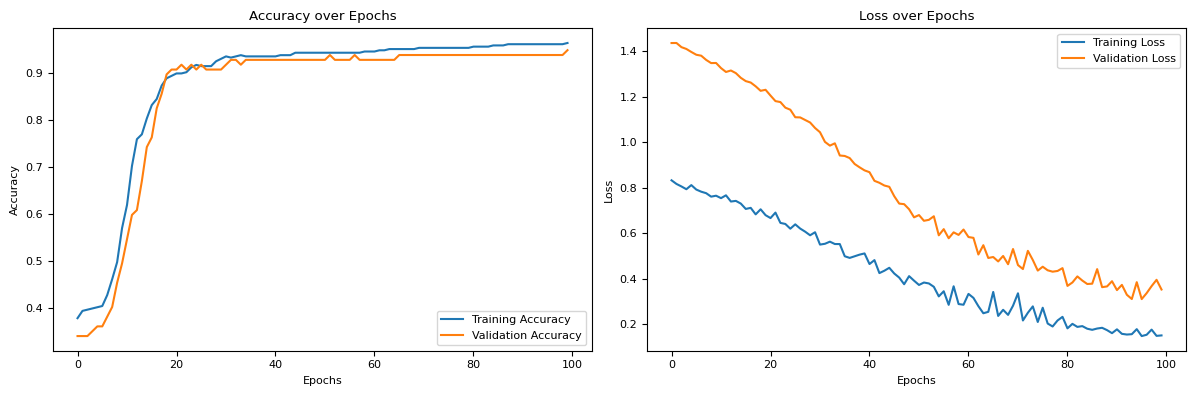

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(range(epochs), train_accuracies, label='Training Accuracy')
axes[0].plot(range(epochs), val_accuracies, label='Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()

# Loss
axes[1].plot(range(epochs), train_losses, label='Training Loss')
axes[1].plot(range(epochs), val_losses, label='Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()


### Testing the model on unseen data

We evaluate the trained model on the test dataset to assess its performance on unseen data. We compute precision and confusion matrix to understand the model's classification performance.

In [51]:
def predictions(model, test_dataloader, device):
    predictions = []
    true_labels = []

    correct_test = 0
    elements = 0

    model.eval()  # set model to evaluation mode
    with torch.no_grad():  # disable gradient computation
        for features, labels in test_dataloader:
            features, labels = features.to(device), labels.to(device)

            outputs = model(features)  # forward pass

            # round converts probabilities to binary predictions 0/1
            # we detach from the computation graph and move to CPU for numpy conversion
            # numpy() requires the tensor to be on CPU and converts to numpy array
            predictions.append(outputs.round().detach().cpu().numpy())
            true_labels.append(labels.detach().cpu().numpy())

            # compute number of correct predictions
            correct_batch = (labels.reshape(-1, 1) == outputs.round()).sum()
            correct_test += correct_batch.detach().cpu().numpy()
            elements += labels.shape[0]  # length of the batch

        predictions = np.vstack(predictions)
        true_labels = np.vstack(true_labels)
        print(f'Test set accuracy: {correct_test / elements*100:.2f}%')

    return predictions, true_labels

In [52]:
predictions, true_labels = predictions(model, test_dataloader, device)

Test set accuracy: 96.51%


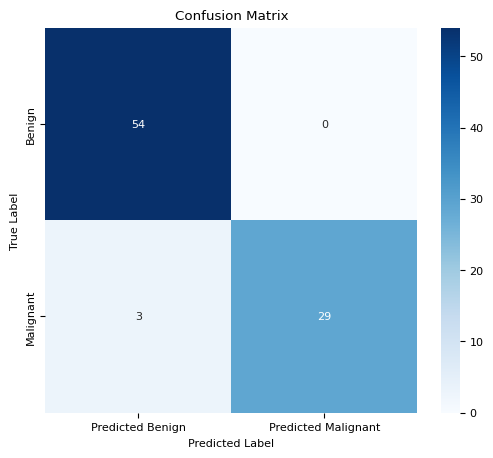

In [57]:
cm = confusion_matrix(true_labels, predictions)

df_cm = pd.DataFrame(cm, index=['Benign', 'Malignant'], columns=['Predicted Benign', 'Predicted Malignant'])
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='g', cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

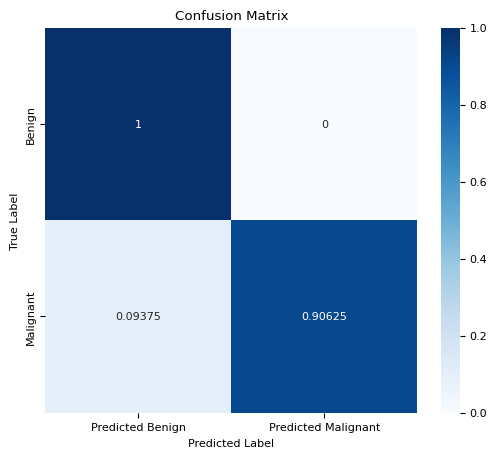

In [ ]:
# normalize the confusion matrix to show proportions
cm = confusion_matrix(true_labels, predictions, normalize='true')

df_cm = pd.DataFrame(cm, index=['Benign', 'Malignant'], columns=['Predicted Benign', 'Predicted Malignant'])
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='g', cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Precision of 96.51% with 3 false negatives and 0 false positives indicates strong model performance in identifying malignant cases.